<a href="https://colab.research.google.com/github/AlexandrCherezov/retail-insurance-anomaly-detection/blob/main/kasko_anomaly_and_dependencies_analysisC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ выборки ФЛ с/без КАСКО на наличие аномалий и значимых зависимостей



## Оглавление
- ##### [Постановка задачи](#1)
- ##### [Импорт библиотек, заведение функций](#2)
- ##### [Загрузка данных](#3)
- ##### [Обработка данныхи](#4)
- ##### [Исследование](#5)
- ##### [Визуализация](#6)

## 1
# Постановка задачи

Описание задачи:
В файле приведены выборка данных о зарплате, возрасте и наличии страховки каско у жителей крупных городов России.

Необходимо:
- проанализировать выборку на наличие аномалий и значимых зависимостей
- кратко изложить описание выборки и результаты анализа.


## 2
# Импорт библиотек

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Перейдем в папку с данными
import os
os.chdir('/content/drive/MyDrive/Тест_РНПК')

In [ ]:
os.listdir()

['Test case - Regression (task) (3).xlsx',
 'лайфхаки кода Python.docx',
 'test_RNPC.ipynb',
 'РНПК_аналитический_отчет.gdoc',
 'РНПК_аналитический_отчет.pdf',
 'test_RNRC.ipynb']

In [ ]:
# для извлечения и анализа данных
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import warnings
warnings.simplefilter('ignore')

In [ ]:
print(f'\033[1;34mНачали расчет {datetime.datetime.now().strftime("%d.%m.%Y в %H:%M")}\033[0m')

Начали расчет 23.08.2026 в 19:32


### 2.2 Создание функций

In [ ]:
# Функция загрузки данных формата csv в датафреймы и проверки основных параметров
def looking_for_data(df):
    print("\033[34m" "\033[1m" "Первые строки датафрейма")
    display(df.head(5))

    print("\033[34m" "\033[1m" "Информация о типах данных")
    print()
    display(df.info(memory_usage='deep'))

    print("\033[34m" "\033[1m" "Доля пропущенных значений ")
    pd.set_option('display.float_format', '{:.1%}'.format)
    display(df.isna().mean())
    pd.reset_option('display.float_format')

    print("\033[34m" "\033[1m" "Количество явных дубликатов ")
    display(df.duplicated().sum())

    print("\033[34m" "\033[1m" "Распределение параметров ")
    display(df.describe().round())

    # Уникальные значения в столбцах:
    # see_unique(df)
    for i in df.columns[0:]:
        print(f'\033[33m\033[1mСтолбец: {i}')
        print(f'\033[34mКоличество уникальных значений: \033[35m {df[i].nunique()}')
        if df[i].nunique() <= 10:
            print(f'\033[34mУникальные значения: \033[35m {(df[i].unique())}')
        else:
            print(f'\033[34mПервые 10 уникальных значений: \033[35m {(df[i].unique()[:10])}')

    return

In [ ]:
# Создадим функцию для построения гистограммы
def orders_distr_mark(df, event, ax, bins):
    df.plot(y=event
            , kind = 'hist'
            , figsize=(12,3)
            , bins=bins
            , ax = ax
            , grid=True
            , legend=False)
    plt.title(f'Распределение \nпо {event}\n ', fontsize=16, color = "b")
    plt.xlabel(f"{event}", fontsize = 12, color = "b")
    plt.ylabel("Количество событий", fontsize = 12, color = "b")
    plt.tick_params(axis='both', labelsize=8)
    plt.axvline (x=np.nanmean (df[event]), color='green', linestyle='--', linewidth= 3 , label='Avg')
    plt.axvline (x=df[event].median() , color='red', linestyle='-.', linewidth= 3 , label='Median')

    return

In [ ]:
# Для построения двух графиков на одном поле
def plot_two_in_one(df, event1, event2, bins1, bins2):
    # задаём размер сетки для графиков
    plt.figure(figsize=(50, 8))
    # строим распределение в первой ячейке
    ax1 = plt.subplot(1, 2, 1)
    orders_distr_mark(df, event1, ax1, bins1)
    # строим распределение во второй ячейке
    ax2 = plt.subplot(1, 2, 2)
    orders_distr_mark(df, event2, ax2, bins2)
    plt.savefig('age_and_income_distributions.png', bbox_inches='tight', dpi=100)

    return

## 3
# Загрузим и познакомимся с данными

In [ ]:
# Считываем первые 20 строк файла целиком "как есть"
file_name = 'Test case - Regression (task) (3).xlsx'
raw_df = pd.read_excel(file_name, header=None, nrows=20)
# находим индекс первой строки, где нет пустых значений
header_row_index = raw_df.dropna(how='all').index[0]
# загрузим файл полностью
df = pd.read_excel(file_name, skiprows=header_row_index)

In [ ]:
# познакомимся с данными
looking_for_data(df)

Первые строки датафрейма


,City,Gender,Age,Income,KASKO_flg
0,Москва,Female,49,30000,0
1,Санкт-Петербург,Male,38,135000,0
2,Новосибирск,Male,41,70000,0
3,Екатеринбург,Female,27,127000,0
4,Казань,Male,52,125000,0


Информация о типах данных

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   City       40000 non-null  str  
 1   Gender     40000 non-null  str  
 2   Age        40000 non-null  int64
 3   Income     40000 non-null  int64
 4   KASKO_flg  40000 non-null  int64
dtypes: int64(3), str(2)
memory usage: 2.4 MB


None

Доля пропущенных значений 


...

Количество явных дубликатов 


np.int64(2564)

Распределение параметров 


,Age,Income,KASKO_flg
count,40000.0,40000.0,40000.0
mean,40.0,109766.0,0.0
std,9.0,51969.0,0.0
min,25.0,20000.0,0.0
25%,32.0,65000.0,0.0
50%,40.0,110000.0,0.0
75%,48.0,154000.0,1.0
max,55.0,200000.0,1.0


Столбец: City
Количество уникальных значений:  16
Первые 10 уникальных значений:  <ArrowStringArray>
[         'Москва', 'Санкт-Петербург',     'Новосибирск',    'Екатеринбург',
          'Казань', 'Нижний Новгород',      'Красноярск',       'Челябинск',
          'Самара',             'Уфа']
Length: 10, dtype: str
Столбец: Gender
Количество уникальных значений:  2
Уникальные значения:  <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Столбец: Age
Количество уникальных значений:  31
Первые 10 уникальных значений:  [49 38 41 27 52 34 48 32 54 28]
Столбец: Income
Количество уникальных значений:  181
Первые 10 уникальных значений:  [ 30000 135000  70000 127000 125000 112000  41000  71000 137000 142000]
Столбец: KASKO_flg
Количество уникальных значений:  2
Уникальные значения:  [0 1]


Обработаем:
- названия столбцов приведем к нижнему регистру
- каждой записи прсвоим индивидуальный ID. Для эффективного расходования ресурсов назначим целочисленный тип этого поля
- оптимизируем текстовые поля `City` и `Gender`в категории
- переведем флаг КАСКО в минимальный целочисленный тип (8 бит вместо 64)
- категоризируем возраст и доход, добавим новые поля

## 4
# Обработаем данные

In [ ]:
# Названия столбцов приведем к стилю lower_case_with_underscores
df.columns = df.columns.str.lower().str.replace(' ','_')

In [ ]:
# каждой записи прсвоим индивидуальный ID
df.index = df.index + 1
df.index.name = 'client_id'
df = df.reset_index()

In [ ]:
# Оптимизируем текстовые поля в категории
for col in ['gender', 'city']:
    df[col] = df[col].astype('category')
# Переводим флаг КАСКО в минимальный целочисленный тип
df['kasko_flg'] = df['kasko_flg'].astype('int8')
# переведем client_id в int32
df['client_id'] = df['client_id'].astype('int32')
# Проверяем, сколько памяти мы сэкономили
df.info(memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   client_id  40000 non-null  int32   
 1   city       40000 non-null  category
 2   gender     40000 non-null  category
 3   age        40000 non-null  int64   
 4   income     40000 non-null  int64   
 5   kasko_flg  40000 non-null  int8    
dtypes: category(2), int32(1), int64(2), int8(1)
memory usage: 899.0 KB


In [ ]:
# Категоризируем возраст на логические группы
# для универсальности решения добавим категории до 26 и более 55 лет
age_bins = [0, 30, 35, 40, 45, 50, 55, 100]
age_labels = ['до 30', '31-35', '36-40', '41-45', '46-50', '51-56', 'от 56']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Категоризируем доход на 4 равные группы по квантилям (от низкого к высокому)
df['income_group'] = pd.qcut(df['income'], q=4, labels=['низкий', 'средний', 'высокий', 'бизнес'])


In [ ]:
# Посмотрим, как распределились клиенты
for col in ['city', 'gender', 'kasko_flg', 'age_group', 'income_group']:
    print(f'************** {col} ****************')
    df1 = df.groupby(col).agg({'client_id':'nunique'})
    df1['pie_%'] = round(df1.client_id / df1.client_id.sum() * 100, 2)
    display(df1)

************** city ****************


,client_id,pie_%
city,,
Волгоград,2500,6.25
Воронеж,2500,6.25
Екатеринбург,2500,6.25
Казань,2500,6.25
Краснодар,2500,6.25
Красноярск,2500,6.25
Москва,2500,6.25
Нижний Новгород,2500,6.25
Новосибирск,2500,6.25


************** gender ****************


,client_id,pie_%
gender,,
Female,19739,49.35
Male,20261,50.65


************** kasko_flg ****************


,client_id,pie_%
kasko_flg,,
0,27023,67.56
1,12977,32.44


************** age_group ****************


,client_id,pie_%
age_group,,
до 30,7681,19.20
31-35,6420,16.05
36-40,6428,16.07
41-45,6530,16.32
46-50,6482,16.20
51-56,6459,16.15


************** income_group ****************


,client_id,pie_%
income_group,,
низкий,10185,25.46
средний,9946,24.86
высокий,9903,24.76
бизнес,9966,24.92


<div class = 'alert alert-info'>
    
### по итогам трансформации и изучения:
- нам удалось в 3 раза снизить объем занимаемой оперативной памяти - с 2.7 МБ до 0.9 МБ
- ФЛ в равных количествах распределены между городами - по 2500 человек вкаждом городе
- раздичие в долях между мужчинами и женщинами незначительное
- распределение в возрастных группах достаточно равномерное. в группе до 30 лет прмерно на 1300 человек больше за счет бОльшего диапазона возраста
- распределение в группах по доходу также достаточно равномерное
- примерно третья часть имеет страховку КАСКО
</div>

## 5
# Исследование

### 5.1 РАСЧЕТ ПРОНИКНОВЕНИЯ КАСКО

In [ ]:
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ДЛЯ АНАЛИТИЧЕСКОГО ОТЧЕТА (% КАСКО)")
print("="*50)

print("\n1. Зависимость от Пола:")
print((df.groupby('gender')['kasko_flg'].mean() * 100).round(2))

print("\n2. Зависимость от Возрастной группы:")
print((df.groupby('age_group')['kasko_flg'].mean() * 100).round(2))

print("\n3. Зависимость от Уровня дохода:")
print((df.groupby('income_group')['kasko_flg'].mean() * 100).round(2))

print("\n4. Распределение КАСКО по городам (Топ-10 по % проникновения):")
city_stats = df.groupby('city')['kasko_flg'].agg(['count', 'mean'])
city_stats['kasko_pct'] = (city_stats['mean'] * 100).round(2)
print(city_stats.sort_values(by='kasko_pct', ascending=False).head(10)[['count', 'kasko_pct']])

print("\n5. Сегментация: Топ-15 перекрестных групп с МАКСИМАЛЬНЫМ КАСКО:")
segments = df.groupby(['gender', 'age_group', 'income_group'])['kasko_flg'].agg(['count', 'mean'])
segments['kasko_pct'] = (segments['mean'] * 100).round(2)
# Оставляем только репрезентативные группы (более 100 человек)
valid_segments = segments[segments['count'] > 100]
print(f'Количество строк (групп) = {valid_segments.shape[0]}')
print(valid_segments.sort_values(by='kasko_pct', ascending=False).head(15)[['count', 'kasko_pct']])


РЕЗУЛЬТАТЫ ДЛЯ АНАЛИТИЧЕСКОГО ОТЧЕТА (% КАСКО)

1. Зависимость от Пола:
gender
Female    30.23
Male      34.60
Name: kasko_flg, dtype: float64

2. Зависимость от Возрастной группы:
age_group
до 30    38.39
31-35    36.76
36-40    35.75
41-45    31.90
46-50    28.25
51-56    22.54
Name: kasko_flg, dtype: float64

3. Зависимость от Уровня дохода:
income_group
низкий     23.73
средний    32.37
высокий    35.68
бизнес     38.20
Name: kasko_flg, dtype: float64

4. Распределение КАСКО по городам (Топ-10 по % проникновения):
                 count  kasko_pct
city                             
Уфа               2500      34.52
Москва            2500      34.28
Ростов-на-Дону    2500      33.64
Воронеж           2500      33.00
Волгоград         2500      32.84
Казань            2500      32.44
Челябинск         2500      32.32
Санкт-Петербург   2500      32.28
Екатеринбург      2500      32.24
Новосибирск       2500      32.20

5. Сегментация: Топ-15 перекрестных групп с МАКСИМАЛЬНЫМ КАСКО:
Ко

In [ ]:
print("\n5. Сегментация: Топ-15 перекрестных групп с МИНИМАЛЬНЫМ КАСКО:")
segments = df.groupby(['gender', 'age_group', 'income_group'])['kasko_flg'].agg(['count', 'mean'])
segments['kasko_pct'] = (segments['mean'] * 100).round(2)
# Оставляем только репрезентативные группы (более 100 человек)
valid_segments = segments[segments['count'] > 100]
print(f'Количество строк (групп) = {valid_segments.shape[0]}')
print(valid_segments.sort_values(by='kasko_pct', ascending=False).tail(15)[['count', 'kasko_pct']])


5. Сегментация: Топ-15 перекрестных групп с МИНИМАЛЬНЫМ КАСКО:
Количество строк (групп) = 48
                               count  kasko_pct
gender age_group income_group                  
Female 46-50     низкий          847      26.33
       51-56     низкий          815      24.79
Male   46-50     высокий         765      24.58
       41-45     низкий          871      24.34
Female 41-45     низкий          766      23.37
       до 30     средний         884      22.29
Male   46-50     средний         842      20.67
Female 36-40     низкий          819      20.51
Male   51-56     бизнес          858      18.18
                 высокий         820      15.00
Female 31-35     низкий          834      14.99
       до 30     низкий          961      12.28
Male   46-50     низкий          829      11.22
       51-56     средний         832       7.81
                 низкий          808       0.37


<div class = 'alert alert-info'>

## низкое проникновение каско у мужчин в возрасте от 46 до 56 лет с доходом "высокий" и "бизнес"

### 5.2. Посмотрим, какое проникновение страховки у женщин


In [ ]:
print("\n5. Сегментация: ЖЕНЩИНЫ:")
segments = df.query('gender == "Female"').groupby(['gender', 'age_group', 'income_group'])['kasko_flg'].agg(['count', 'mean'])
segments['kasko_pct'] = (segments['mean'] * 100).round(2)
# Оставляем только репрезентативные группы (более 100 человек)
valid_segments = segments[segments['count'] > 100]
print(f'Количество строк (групп) = {valid_segments.shape[0]}')
print(valid_segments.sort_values(by='kasko_pct', ascending=False)[['count', 'kasko_pct']])


5. Сегментация: ЖЕНЩИНЫ:
Количество строк (групп) = 24
                               count  kasko_pct
gender age_group income_group                  
Female 51-56     бизнес          781      41.36
       46-50     высокий         835      39.76
                 бизнес          773      38.68
       36-40     бизнес          787      38.12
       51-56     высокий         779      38.00
                 средний         766      37.60
       31-35     бизнес          786      35.62
       41-45     высокий         845      35.62
       36-40     высокий         785      35.41
       41-45     бизнес          799      35.17
       46-50     средний         771      34.37
       41-45     средний         775      33.29
       до 30     высокий         985      31.57
                 бизнес          948      30.70
       31-35     средний         780      27.56
                 высокий         803      27.40
       36-40     средний         815      26.63
       46-50     низкий         

<div class = 'alert alert-info'>
    
- У мужчин чаще всего страхуется молодежь до 30 лет (свыше 52–56%).
- У женщин лидером являются женщины в возрасте 51–56 лет с доходом «бизнес» — у них самый высокий показатель (41.36%).
- Молодые девушки и женщины до 30 лет, даже с высоким доходом, страхуются неохотно (всего 30–31%).
- Влияние дохода у женщин: Здесь фактор дохода работает сильнее, чем возраст. Первые 11 строчек с максимальным КАСКО у женщин (от 35% до 41%) — это исключительно категории «бизнес» и «высокий», независимо от возраста.

### 5.3. Лучшие города


In [ ]:
print("\n5. Сегментация: Лучшие города:")
segments = df.query('city.isin(["Уфа", "Ростов-на-Дону", "Воронеж"])').groupby(['gender', 'age_group', 'income_group'])['kasko_flg'].agg(['count', 'mean'])
segments['kasko_pct'] = (segments['mean'] * 100).round(2)
# Оставляем только репрезентативные группы (более 100 человек)
valid_segments = segments[segments['count'] > 100]
print(f'Количество строк (групп) = {valid_segments.shape[0]}')
print(valid_segments.sort_values(by='kasko_pct', ascending=False)[:15][['count', 'kasko_pct']])


5. Сегментация: Лучшие города:
Количество строк (групп) = 48
                               count  kasko_pct
gender age_group income_group                  
Male   до 30     бизнес          186      57.53
                 средний         175      55.43
                 высокий         173      52.02
       31-35     низкий          180      51.67
       до 30     низкий          187      51.34
       31-35     средний         154      51.30
                 высокий         144      50.69
       36-40     высокий         163      50.31
       31-35     бизнес          163      48.47
Female 46-50     бизнес          147      44.90
Male   36-40     средний         142      44.37
                 бизнес          140      43.57
                 низкий          155      42.58
Female 51-56     средний         151      41.72
       46-50     высокий         156      41.67


<div class = 'alert alert-info'>

Анализ топ-3 регионов с максимальным проникновением услуги показывает: фактор низкого дохода не является барьером для покупки КАСКО среди мужчин в возрасте до 40 лет. <br>
Проверим чуть позже - присутствует ли эта закономерность в других городах.

### 5.4. Распределение по возрасту и доходу

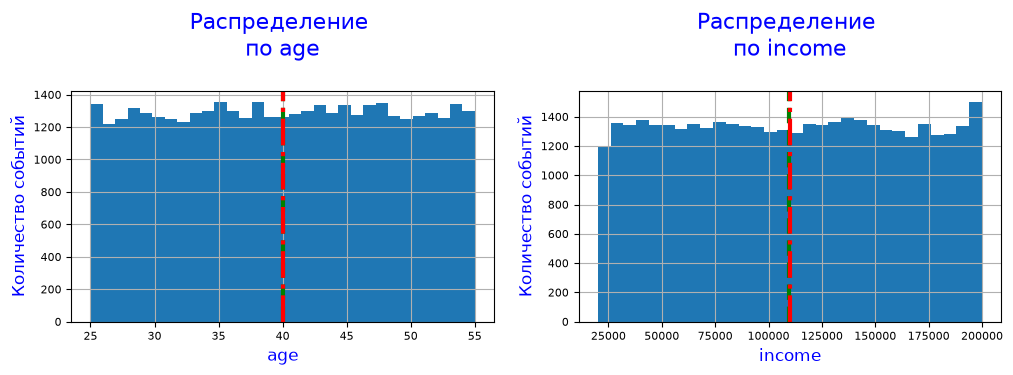

In [ ]:
# вызовем функцию plot_two_in_one
plot_two_in_one(df, 'age', 'income', 31, 30)

<div class = 'alert alert-info'>

**Анализ распределения признака Age (Возраст):**
- Визуальный анализ гистограммы распределения возраста выявил выраженную аномалию: распределение является строго равномерным, а не нормальным.
- На каждый возрастной год приходится одинаковое количество наблюдений (в среднем ~1300 событий).Стандартное отклонение std = 9.0 при среднем mean = 40.0 обусловлено исключительно границами интервала выборки.
- **Вывод**: Данный характер распределения указывает на синтетическую (искусственную) природу формирования исходного датасета. У нас нет перекосов в сторону "молодых" или "пожилых" водителей на уровне исходных данных — все возраста представлены в равной степени, что гарантирует одинаковую точность оценок для любого возраста.

**Аналогичное наблюдение и вывод по параметру Income (Доход)**

## 6
# Визуализация. Построим тепловые карты

### КАСКО в разрезе Возраста и Дохода

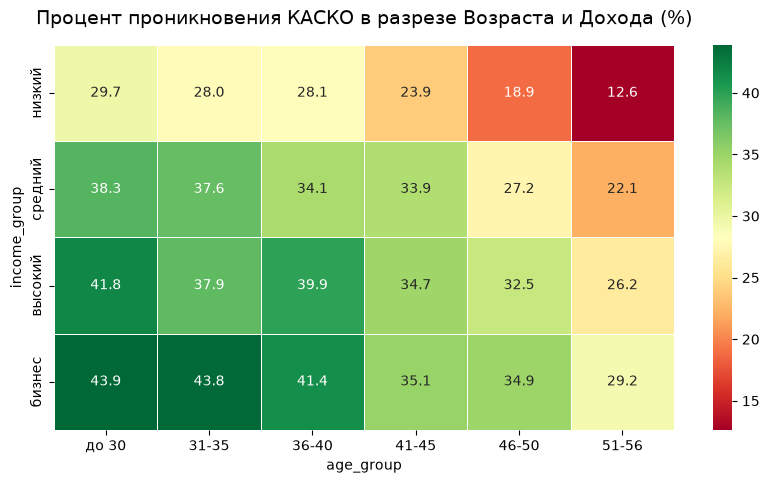

In [ ]:
# КАСКО в разрезе Возраста и Дохода
pivot_kasko = df.pivot_table(columns='age_group',
                             index='income_group',
                             values='kasko_flg',
                             aggfunc='mean') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_kasko, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5)
plt.title('Процент проникновения КАСКО в разрезе Возраста и Дохода (%)', fontsize=14, pad=15)
plt.show()


### КАСКО в разрезе гендера, возраста и дохода

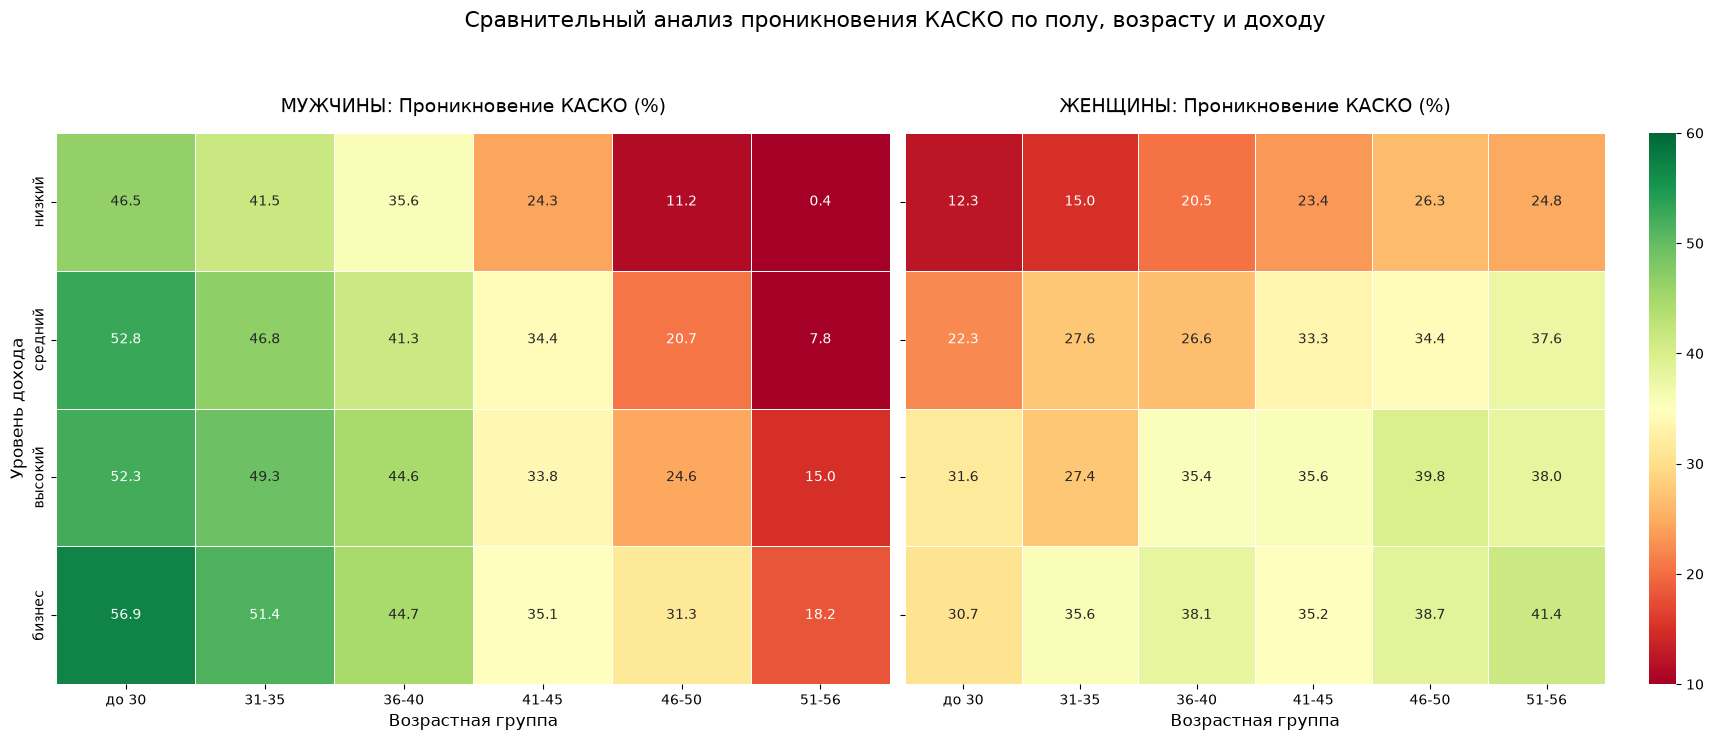

In [ ]:
# КАСКО в разрезе гендера, возраста и дохода
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True,
                               gridspec_kw={'width_ratios': [1, 1.05]})

color_map = 'RdYlGn'


# КАРТА 1: МУЖЧИНЫ (MALE)

male_df = df[df['gender'] == 'Male']
pivot_male = male_df.pivot_table(columns='age_group',
                                 index='income_group',
                                 values='kasko_flg',
                                 aggfunc='mean') * 100

sns.heatmap(pivot_male, annot=True, fmt='.1f', cmap=color_map,
            vmin=10, vmax=60, linewidths=0.5, ax=ax1, cbar=False)
ax1.set_title('МУЖЧИНЫ: Проникновение КАСКО (%)', fontsize=14, pad=15)
ax1.set_xlabel('Возрастная группа', fontsize=12)
ax1.set_ylabel('Уровень дохода', fontsize=12)


# КАРТА 2: ЖЕНЩИНЫ (FEMALE)

female_df = df[df['gender'] == 'Female']
pivot_female = female_df.pivot_table(columns='age_group',
                                     index='income_group',
                                     values='kasko_flg',
                                     aggfunc='mean') * 100

# Рисуем карту на второй оси ax2
sns.heatmap(pivot_female, annot=True, fmt='.1f', cmap=color_map,
            vmin=10, vmax=60, linewidths=0.5, ax=ax2, cbar=True)
ax2.set_title('ЖЕНЩИНЫ: Проникновение КАСКО (%)', fontsize=14, pad=15)
ax2.set_xlabel('Возрастная группа', fontsize=12)
ax2.set_ylabel('') # Убираем дублирование подписи оси Y

# Общий заголовок
plt.suptitle('Сравнительный анализ проникновения КАСКО по полу, возрасту и доходу', fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('kasko_heatmaps.png')
plt.show()


### Проведем статистический тест

In [ ]:
print("\n" + "="*60)
print("СТАТИСТИЧЕСКОЕ ТЕСТИРОВАНИЕ ГИПОТЕЗ (КРИТЕРИЙ ХИ-КВАДРАТ)")
print("="*60)

# Проверяем статистическую значимость различий между МУЖЧИНАМИ и ЖЕНЩИНАМИ
contingency_gender = pd.crosstab(df['gender'], df['kasko_flg'])
chi2, p_gender, dof, expected = chi2_contingency(contingency_gender)

print(f"Гипотеза: Зависит ли наличие КАСКО от Пола?")
print(f"-> Значение критерия Хи-квадрат: {chi2:.2f}")
print(f"-> p-value: {p_gender}")
if p_gender < 0.05:
    print("Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Пол влияет на покупку КАСКО.")
else:
    print("Результат: Различия НЕ значимы.")

# Проверяем статистическую значимость различий между ВОЗРАСТНЫМИ ГРУППАМИ
contingency_age = pd.crosstab(df['age_group'], df['kasko_flg'])
_, p_age, _, _ = chi2_contingency(contingency_age)

print(f"\nГипотеза: Зависит ли наличие КАСКО от Возрастной группы?")
print(f"-> p-value: {p_age}")
if p_age < 0.05:
    print("Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Возраст критически влияет на покупку.")

# 3. Проверяем статистическую значимость различий между ГРУППАМИ ДОХОДА
contingency_income = pd.crosstab(df['income_group'], df['kasko_flg'])
_, p_income, _, _ = chi2_contingency(contingency_income)

print(f"\nГипотеза: Зависит ли наличие КАСКО от Группы дохода?")
print(f"-> p-value: {p_income}")
if p_income < 0.05:
    print("Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Доход критически влияет на покупку.")



СТАТИСТИЧЕСКОЕ ТЕСТИРОВАНИЕ ГИПОТЕЗ (КРИТЕРИЙ ХИ-КВАДРАТ)
Гипотеза: Зависит ли наличие КАСКО от Пола?
-> Значение критерия Хи-квадрат: 86.88
-> p-value: 1.1546577748644876e-20
Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Пол влияет на покупку КАСКО.

Гипотеза: Зависит ли наличие КАСКО от Возрастной группы?
-> p-value: 3.555476773116983e-117
Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Возраст критически влияет на покупку.

Гипотеза: Зависит ли наличие КАСКО от Группы дохода?
-> p-value: 5.017956138953584e-119
Результат: Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05). Доход критически влияет на покупку.


### КАСКО в разрезе города-лидеры и остальные регионы, возраста и дохода

Карта географии успешно сохранена в файл 'kasko_geography_heatmap.png'


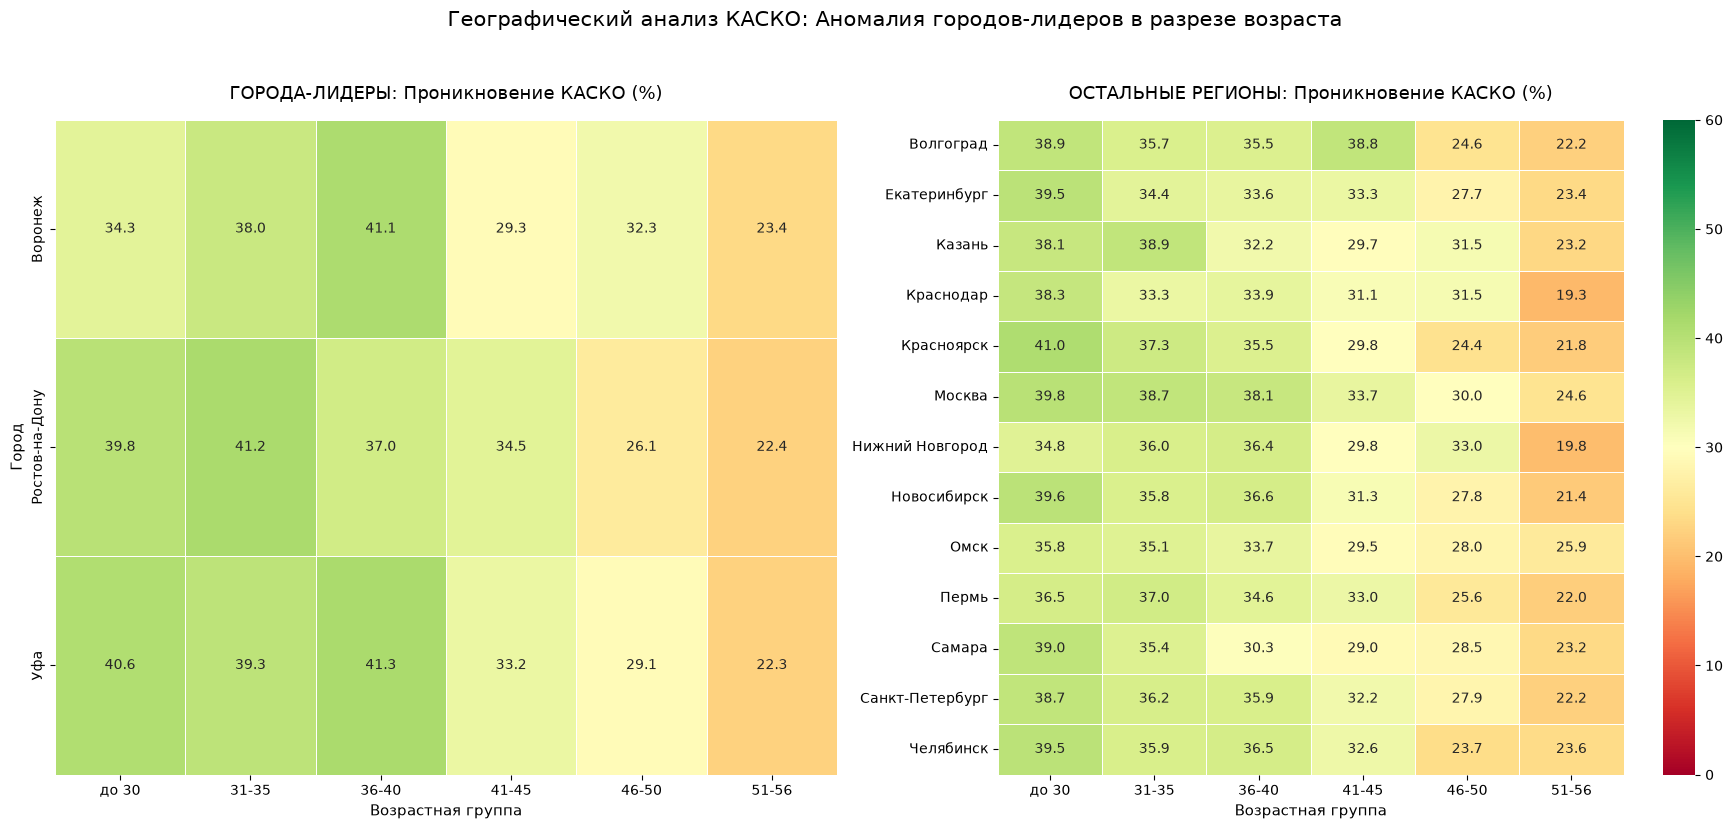

In [ ]:
# Разделяем датасет на города-лидеры и остальные регионы
leaders_cities = ['Уфа', 'Ростов-на-Дону', 'Воронеж']
df_leaders = df[df['city'].isin(leaders_cities)]
df_others = df[~df['city'].isin(leaders_cities)]

# Создаем подложку для двух графиков бок о бок (фиксируем размеры через ax1 и ax2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
color_map = 'RdYlGn'


# КАРТА 1: ГОРОДА-ЛИДЕРЫ (Уфа, Ростов, Воронеж)

# Строим матрицу: Город / Возраст для лидеров
pivot_leaders = df_leaders.pivot_table(columns='age_group',
                                       index='city',
                                       values='kasko_flg',
                                       aggfunc='mean',
                                       observed=False) * 100

# Дропаем города, которых нет в этой подвыборке, чтобы не было пустых строк
pivot_leaders = pivot_leaders.dropna(how='all')

sns.heatmap(pivot_leaders, annot=True, fmt='.1f', cmap=color_map,
            vmin=0, vmax=60, linewidths=0.5, ax=ax1, cbar=False)
ax1.set_title('ГОРОДА-ЛИДЕРЫ: Проникновение КАСКО (%)', fontsize=13, pad=15)
ax1.set_xlabel('Возрастная группа', fontsize=11)
ax1.set_ylabel('Город', fontsize=11)


# КАРТА 2: ОСТАЛЬНЫЕ ГОРОДА МИЛЛИОННИКИ

pivot_others = df_others.pivot_table(columns='age_group',
                                     index='city',
                                     values='kasko_flg',
                                     aggfunc='mean',
                                     observed=False) * 100
pivot_others = pivot_others.dropna(how='all')

sns.heatmap(pivot_others, annot=True, fmt='.1f', cmap=color_map,
            vmin=0, vmax=60, linewidths=0.5, ax=ax2, cbar=True)
ax2.set_title('ОСТАЛЬНЫЕ РЕГИОНЫ: Проникновение КАСКО (%)', fontsize=13, pad=15)
ax2.set_xlabel('Возрастная группа', fontsize=11)
ax2.set_ylabel('') # Убираем подпись оси Y справа для аккуратности

# Общий заголовок
plt.suptitle('Географический анализ КАСКО: Аномалия городов-лидеров в разрезе возраста', fontsize=15, y=1.03)
plt.tight_layout()

# Сохраняем новую карту в файл
plt.savefig('kasko_geography_heatmap.png', bbox_inches='tight', dpi=300)
print("Карта географии успешно сохранена в файл 'kasko_geography_heatmap.png'")
plt.show()


### КАСКО в разрезе Москва и регионы, возраста и дохода

Карта 'Москва vs Регионы' успешно сохранена в файл 'kasko_moscow_vs_regions.png'


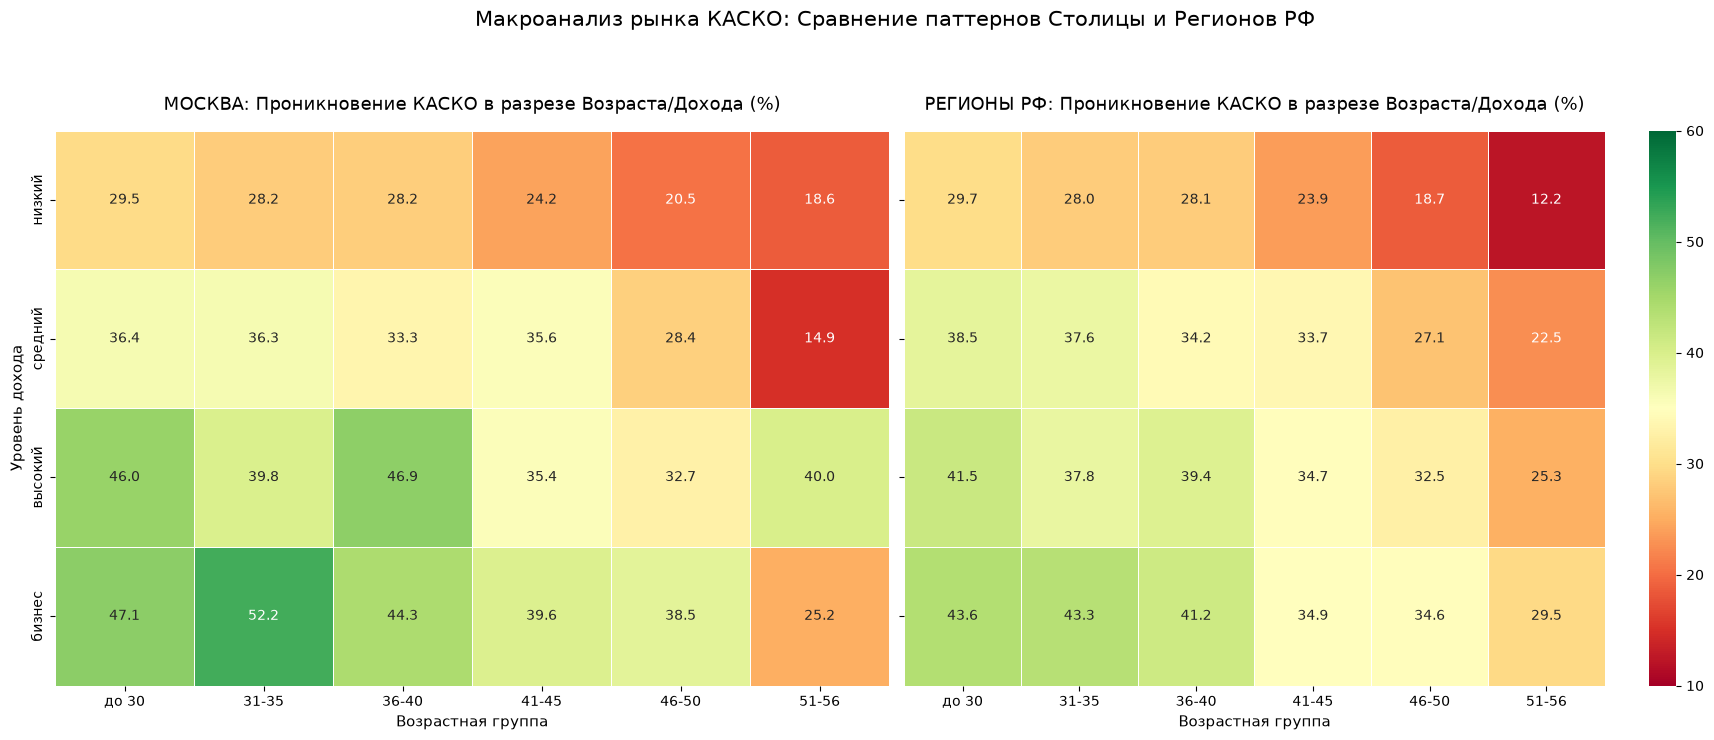

In [ ]:
# Разделяем датасет на Москву и регионы
df_moscow = df[df['city'] == 'Москва']
df_regions = df[df['city'] != 'Москва']

# Создаем подложку для двух графиков бок о бок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True,
                               gridspec_kw={'width_ratios': [1, 1.05]})
color_map = 'RdYlGn'


# КАРТА 1: МОСКВА

pivot_moscow = df_moscow.pivot_table(columns='age_group',
                                     index='income_group',
                                     values='kasko_flg',
                                     aggfunc='mean',
                                     observed=False) * 100

sns.heatmap(pivot_moscow, annot=True, fmt='.1f', cmap=color_map,
            vmin=10, vmax=60, linewidths=0.5, ax=ax1, cbar=False)
ax1.set_title('МОСКВА: Проникновение КАСКО в разрезе Возраста/Дохода (%)', fontsize=13, pad=15)
ax1.set_xlabel('Возрастная группа', fontsize=11)
ax1.set_ylabel('Уровень дохода', fontsize=11)


# КАРТА 2: ОСТАЛЬНАЯ РОССИЯ (РЕГИОНЫ)

pivot_regions = df_regions.pivot_table(columns='age_group',
                                       index='income_group',
                                       values='kasko_flg',
                                       aggfunc='mean',
                                       observed=False) * 100

sns.heatmap(pivot_regions, annot=True, fmt='.1f', cmap=color_map,
            vmin=10, vmax=60, linewidths=0.5, ax=ax2, cbar=True)
ax2.set_title('РЕГИОНЫ РФ: Проникновение КАСКО в разрезе Возраста/Дохода (%)', fontsize=13, pad=15)
ax2.set_xlabel('Возрастная группа', fontsize=11)
ax2.set_ylabel('') # Убираем дублирование оси Y

plt.suptitle('Макроанализ рынка КАСКО: Сравнение паттернов Столицы и Регионов РФ', fontsize=15, y=1.05)
plt.tight_layout()

# Сохраняем карту в файл
plt.savefig('kasko_moscow_vs_regions.png', bbox_inches='tight', dpi=300)
print("Карта 'Москва vs Регионы' успешно сохранена в файл 'kasko_moscow_vs_regions.png'")
plt.show()


In [ ]:
print(f'\033[1;34mЗавершили расчет {datetime.datetime.now().strftime("%d.%m.%Y в %H:%M)")}')

Завершили расчет 23.08.2026 в 11:59)
